# Part 2: Extension with XGBoost

**Why XGBoost?** The reference paper uses gradient boosting (GBM), bagging and random forest, but not XGBoost.
XGBoost is a regularised, optimised gradient-boosting implementation (L1/L2 penalties on leaf weights, row and column
subsampling, shrinkage), so it is a natural, fair comparison against the paper's best tree-based model (GBM) and
against logistic regression, the paper's overall winner. On a small tabular dataset (303 rows) its regularisation
is the main thing that should help it avoid overfitting.

**Fairness:** same dataset, same 60/20/20 stratified split (same `RANDOM_STATE` as Part 1), same cross-validation
scheme (3x repeated 10-fold, scored on F1) and same metrics as Part 1.

In [9]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, RandomizedSearchCV, RepeatedStratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
                             RocCurveDisplay, PrecisionRecallDisplay, ConfusionMatrixDisplay)
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

# !!! MUST be identical to RANDOM_STATE in part1_reproduction.ipynb (search that notebook for RANDOM_STATE) !!!
RANDOM_STATE = 42

DATA_PATH = os.path.join("..", "data", "heart.csv")
RESULTS_DIR = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)
np.random.seed(RANDOM_STATE)

## 1. Load data

In [10]:
df = pd.read_csv(DATA_PATH)
TARGET = "output" if "output" in df.columns else "target"   # Kaggle file uses 'output'
X = df.drop(columns=[TARGET])
y = df[TARGET]
print(df.shape, "| target:", TARGET, "| class counts:", y.value_counts().to_dict())

(303, 14) | target: output | class counts: {1: 165, 0: 138}


## 2. Same 60/20/20 split as Part 1

In [11]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.40,
    random_state=RANDOM_STATE,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=y_temp
)

print("Training:", X_train.shape[0], "| Validation:", X_val.shape[0], "| Test:", X_test.shape[0])

Training: 181 | Validation: 61 | Test: 61


## 3. Tune XGBoost (training set only, 3x10-fold CV, scored on F1)
No feature scaling is needed for tree models.

In [12]:
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=RANDOM_STATE)

param_dist = {
    "n_estimators":     [50, 100, 200, 300, 500],
    "learning_rate":    [0.01, 0.05, 0.1, 0.25, 0.5],
    "max_depth":        [2, 3, 4, 5, 6],
    "subsample":        [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "min_child_weight": [1, 3, 5],
    "reg_lambda":       [0.1, 1, 10],
}

search = RandomizedSearchCV(
    XGBClassifier(eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=1),
    param_dist, n_iter=60, scoring="f1", cv=cv, n_jobs=-1, random_state=RANDOM_STATE, verbose=1
)
search.fit(X_train, y_train)
xgb = search.best_estimator_
print("Best params:", search.best_params_)
print("Best CV F1 :", round(search.best_score_, 3))

Fitting 30 folds for each of 60 candidates, totalling 1800 fits
Best params: {'subsample': 0.8, 'reg_lambda': 0.1, 'n_estimators': 100, 'min_child_weight': 5, 'max_depth': 3, 'learning_rate': 0.1, 'colsample_bytree': 0.6}
Best CV F1 : 0.874


## 4. Evaluate on validation and test sets (same metrics as Part 1)

In [13]:
def evaluate(model, Xs, ys):
    pred = model.predict(Xs)
    prob = model.predict_proba(Xs)[:, 1]
    return {
        "Accuracy":  accuracy_score(ys, pred),
        "AUROC":     roc_auc_score(ys, prob),
        "Precision": precision_score(ys, pred, zero_division=0),
        "Recall":    recall_score(ys, pred, zero_division=0),
        "F1":        f1_score(ys, pred, zero_division=0),
    }

xgb_val  = pd.Series(evaluate(xgb, X_val,  y_val)).round(2)
xgb_test = pd.Series(evaluate(xgb, X_test, y_test)).round(2)

xgb_results = pd.DataFrame({"Validation": xgb_val, "Test": xgb_test}).T
xgb_results.index.name = "Set"
xgb_results.to_csv(os.path.join(RESULTS_DIR, "xgboost_results.csv"))
xgb_results

,Accuracy,AUROC,Precision,Recall,F1
Set,,,,,
Validation,0.74,0.84,0.71,0.88,0.78
Test,0.82,0.93,0.79,0.91,0.85


## 5. Compare against Part 1 models
This loads the CSVs saved by Part 1. If the column names differ from what is shown, adjust the printout or just
read the numbers off the two tables.

In [14]:
for f in ["validation_results.csv", "test_results.csv"]:
    path = os.path.join(RESULTS_DIR, f)
    print("\n==", f, "==")
    print(pd.read_csv(path).to_string(index=False) if os.path.exists(path) else "NOT FOUND: run Part 1 first")

print("\n== XGBoost (extension) ==")
print(xgb_results.to_string())


== validation_results.csv ==
         Unnamed: 0    AUROC  Precision   Recall       F1  Accuracy
     SVM Polynomial 0.857464   0.769231 0.909091 0.833333  0.800000
      Random Forest 0.859708   0.769231 0.909091 0.833333  0.800000
            Bagging 0.839506   0.738095 0.939394 0.826667  0.783333
        Elastic Net 0.874299   0.738095 0.939394 0.826667  0.783333
         SVM Linear 0.863075   0.738095 0.939394 0.826667  0.783333
  Gradient Boosting 0.870932   0.750000 0.909091 0.821918  0.783333
Logistic Regression 0.876543   0.714286 0.909091 0.800000  0.750000
            SVM RBF 0.869809   0.725000 0.878788 0.794521  0.750000
     Neural Network 0.857464   0.729730 0.818182 0.771429  0.733333

== test_results.csv ==
         Unnamed: 0    AUROC  Precision   Recall       F1  Accuracy
Logistic Regression 0.933983   0.805556 0.878788 0.840580  0.819672
  Gradient Boosting 0.897186   0.800000 0.848485 0.823529  0.803279
            SVM RBF 0.926407   0.820513 0.969697 0.888889  0.8

## 6. Plots: ROC, PR, confusion matrix, feature importance

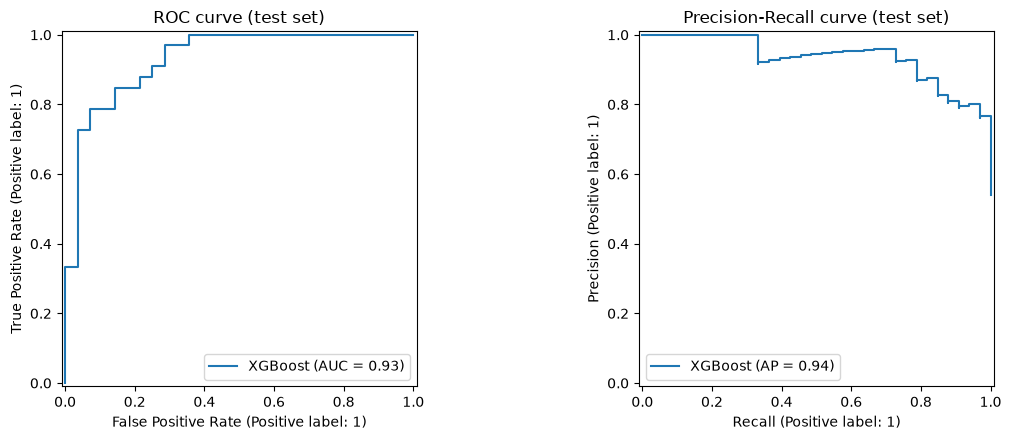

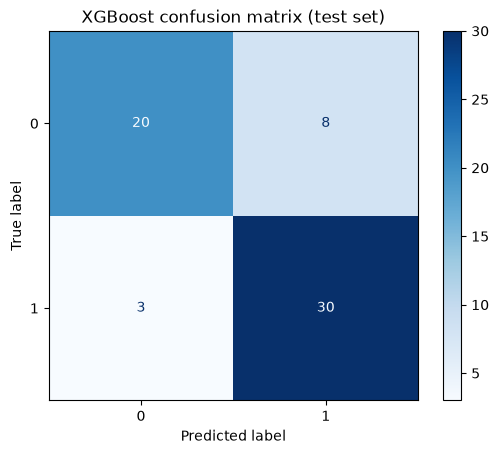

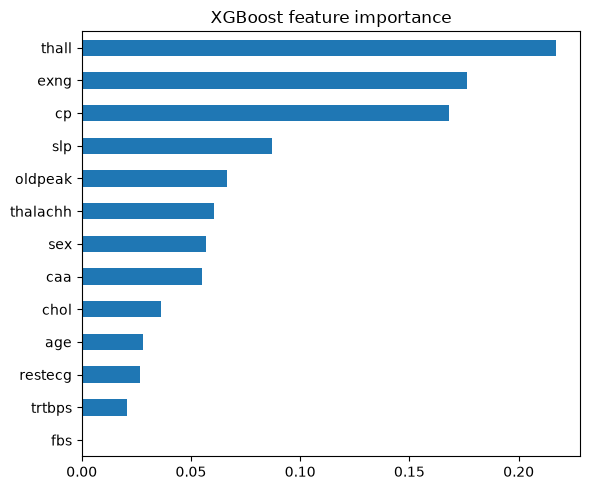

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
RocCurveDisplay.from_estimator(xgb, X_test, y_test, ax=ax[0], name="XGBoost")
PrecisionRecallDisplay.from_estimator(xgb, X_test, y_test, ax=ax[1], name="XGBoost")
ax[0].set_title("ROC curve (test set)"); ax[1].set_title("Precision-Recall curve (test set)")
plt.tight_layout(); plt.savefig(os.path.join(RESULTS_DIR, "xgboost_roc_pr.png"), dpi=150); plt.show()

ConfusionMatrixDisplay.from_estimator(xgb, X_test, y_test, cmap="Blues")
plt.title("XGBoost confusion matrix (test set)")
plt.savefig(os.path.join(RESULTS_DIR, "xgboost_confusion_matrix.png"), dpi=150); plt.show()

imp = pd.Series(xgb.feature_importances_, index=X.columns).sort_values()
imp.plot.barh(figsize=(6, 5), title="XGBoost feature importance")
plt.tight_layout(); plt.savefig(os.path.join(RESULTS_DIR, "xgboost_feature_importance.png"), dpi=150); plt.show()

In [16]:
t = pd.read_csv(os.path.join(RESULTS_DIR, "test_results.csv")).rename(columns={"Unnamed: 0": "Model"})
x = xgb_results.loc[["Test"]].rename(index={"Test": "XGBoost (extension)"}).rename_axis("Model").reset_index()
combined = pd.concat([t, x], ignore_index=True).round(2)
combined = combined[["Model", "Accuracy", "AUROC", "Precision", "Recall", "F1"]].sort_values("F1", ascending=False)
combined.to_csv(os.path.join(RESULTS_DIR, "test_comparison_with_xgboost.csv"), index=False)
combined

,Model,Accuracy,AUROC,Precision,Recall,F1
2,SVM RBF,0.87,0.93,0.82,0.97,0.89
3,Bagging,0.84,0.93,0.81,0.91,0.86
4,Random Forest,0.82,0.93,0.79,0.91,0.85
5,XGBoost (extension),0.82,0.93,0.79,0.91,0.85
0,Logistic Regression,0.82,0.93,0.81,0.88,0.84
1,Gradient Boosting,0.80,0.90,0.80,0.85,0.82


## 7. Conclusion 
XGBoost reached a test F1 of 0.85, AUROC of 0.93 and recall of 0.91. This is comparable to the best reproduced models (Bagging, Random Forest, Logistic Regression) and better than the reference paper's gradient boosting model (F1 0.82, AUROC 0.90), which we attribute to XGBoost's L1/L2 regularisation and row/column subsampling. We do not claim XGBoost is the best model: with only 61 test patients, differences of 1–3 points correspond to one or two patients. Its validation F1 (0.78) was lower than its test F1, but all models scored higher on test than validation, indicating an easier test split rather than a model effect. High recall is clinically desirable for MI risk screening.